Iteration 1: max delta = 0.5000000
Iteration 2: max delta = 0.2287926
Iteration 3: max delta = 0.1045860
Iteration 4: max delta = 0.0712094
Iteration 5: max delta = 0.0585301
Iteration 6: max delta = 0.0486125
Iteration 7: max delta = 0.0408243
Iteration 8: max delta = 0.0349914
Iteration 9: max delta = 0.0306755
Iteration 10: max delta = 0.0273446
Iteration 11: max delta = 0.0246796
Iteration 12: max delta = 0.0224869
Iteration 13: max delta = 0.0206410
Iteration 14: max delta = 0.0190559
Iteration 15: max delta = 0.0176709
Iteration 16: max delta = 0.0164425
Iteration 17: max delta = 0.0153390
Iteration 18: max delta = 0.0143411
Iteration 19: max delta = 0.0134303
Iteration 20: max delta = 0.0125918
Iteration 21: max delta = 0.0118150
Iteration 22: max delta = 0.0110920
Iteration 23: max delta = 0.0104170
Iteration 24: max delta = 0.0097852
Iteration 25: max delta = 0.0091930
Iteration 26: max delta = 0.0086374
Iteration 27: max delta = 0.0081158
Iteration 28: max delta = 0.0076258
I

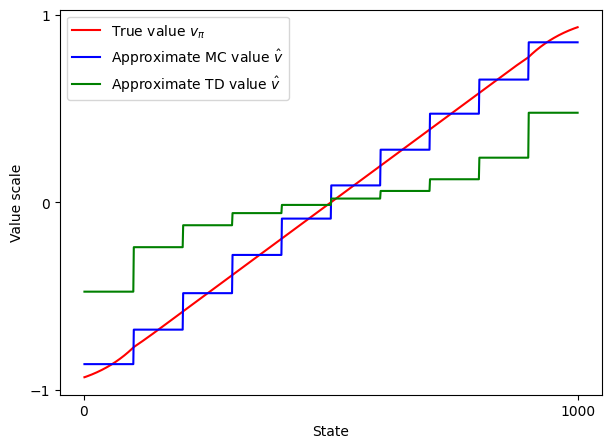

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#environment setup
states_number = 1000 #state 1 - 1000
terminal_left = 0 #define left terminal
terminal_right = states_number + 1 #define right terminal
states = np.arange(1, states_number + 1)
gamma = 1

p_transition = np.zeros((states_number + 2, states_number + 2)) #probability of all states including 0 and 1001, (current state, next state)
reward = np.zeros((states_number + 2, states_number + 2)) #reward of all states including 0 and 1001

for s in range(1, states_number + 1): #loop for 1 - 1000
  neighbors_left = range(max(s - 100, terminal_left + 1), s) #s is not counted in python
  neighbors_right = range(s + 1, min(terminal_right, s + 101))

  #left
  for s_left in neighbors_left:
    p_transition[s][s_left] += 0.5 / len(neighbors_left)

  if s - 100 <= terminal_left:
    p_transition[s][terminal_left] += 0.5 * (terminal_left - (s - 100) + 1) / 100 #the probability that would have fone into those missing neighbors goes into the probability of terminating
    reward[s][terminal_left] = -1
  #right
  for s_right in neighbors_right:
    p_transition[s][s_right] += 0.5 / len(neighbors_right)

  if s + 100 >= terminal_right:
    p_transition[s][terminal_right] += 0.5 * ((s + 100) - terminal_right + 1) / 100 #the probability that would have fone into those missing neighbors goes into the probability of terminating
    reward[s][terminal_right] = 1

#normalize
for s in range(1, states_number + 1):
    row_sum = np.sum(p_transition[s])
    if row_sum > 0:
        p_transition[s] /= row_sum

p_transition[terminal_left][terminal_left] = 1
p_transition[terminal_right][terminal_right] = 1

#true value
V = np.zeros(states_number + 2)
theta = 1e-6
delta = float('inf')
iteration = 0

while delta > theta:
  delta = 0
  V_new = np.zeros(states_number + 2)

  for s in range(1, states_number + 1):
    V_new[s] = np.sum(p_transition[s] * (reward[s] + gamma * V))
    delta = max(delta, abs(V_new[s] - V[s]))

  V = V_new
  iteration += 1
  print(f"Iteration {iteration}: max delta = {delta:.7f}")

true_value = V[1:-1] #except terminal states

#group
groups_number = 10
group_size = states_number // groups_number
alpha = 2e-5
episodes = 100000
grouping = np.array([(s - 1) // group_size for s in range(1, states_number + 1)])

#MC
w = np.zeros(groups_number)

def weight(s):
  if s <= 0 or s > states_number:
    return 0
  group_index = grouping[s-1]
  return w[group_index]

for e in range(episodes):
  start = 500
  episode = [start]
  rewards = []
  s = start

  while True:
    next_probability = p_transition[s]
    s_next = np.random.choice(len(next_probability), p = next_probability)
    r = reward[s][s_next]
    rewards.append(r)
    s = s_next

    if s == terminal_left or s == terminal_right:
      break

    episode.append(s)

  G = sum(rewards)

  for state in episode:
    if 1 <= state <= states_number:
      g = grouping[state - 1]
      w[g] += alpha * (G - weight(state))
  if e % 10000 == 0:
    print(f"Episode {e}: G = {G}, w = {w}")

approximate_MC_value = np.array([weight(s) for s in range(1, states_number + 1)])

#TD(0)
w_td = np.zeros(groups_number)

def weight_td(s):
  if s <= 0 or s > states_number:
    return 0
  group_index = grouping[s-1]
  return w_td[group_index]

for e in range(episodes):
  start = 500
  s = start

  while True:
    next_probability = p_transition[s]
    s_next = np.random.choice(len(next_probability), p = next_probability)
    r = reward[s][s_next]

    if 1 <= s <= states_number:
      g = grouping[s - 1]
      td_target = r + gamma * weight_td(s_next)
      w_td[g] += alpha * (td_target - weight_td(s))

    if s == terminal_left or s == terminal_right:
      break

    s = s_next

  if e % 10000 == 0:
    print(f"Episode {e}: w_td = {w_td}")

approximate_TD_value = np.array([weight_td(s) for s in range(1, states_number + 1)])

plt.figure(figsize=(7, 5))
plt.plot(states, true_value, color='red', label='True value $v_\\pi$')
plt.plot(states, approximate_MC_value, color='blue', label='Approximate MC value $\\hat{v}$')
plt.plot(states, approximate_TD_value, color='green', label='Approximate TD value $\\hat{v}$')

plt.xlabel("State")
plt.ylabel("Value scale")
plt.xticks([0, 1000])
plt.yticks([-1, 0, 1])
plt.legend()
plt.show()